In [141]:
from matplotlib import pyplot as plt
import h5py
import numpy as np
import bacco

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [142]:
import os
os.chdir("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

In [143]:
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/TNG_Family/MTNG/", snap=264)
mtng.fof['halo_pos'][:,0] = (mtng.fof['halo_pos'][:,0] - 125) % 500
mtng.sub['pos'][:,0] = (mtng.sub['pos'][:,0] - 125) % 500

basedir = "/cosmos_storage/simulations/TNG_Family/MTNG-DM-Gadget4/MTNG-L500-2160-A/"

resolution_level = 1

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME
numpart = int(1080**3)

mtng_dm = bacco.Simulation(basedir=basedir, halo_file="groups_265/fof_subhalo_tab_265", sim_format='gadget4_hdf5', fixedPk=True, sigma8=sigma8,\
    tau=tau, ns=ns, numpart=numpart, use_orphans=False, use_ids=False)

2025-11-25 15:57:43,429 bacco.sims : Initialising simulation Default
2025-11-25 15:57:43,438 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-25 15:57:43,444 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-25 15:57:43,498 bacco.sims : ...done in 0.019 s
2025-11-25 15:57:43,501 bacco.sims : Reading 98233510 items for GroupPos


2025-11-25 15:57:50,412 bacco.sims : Reading 90246895 items for SubhaloPos
2025-11-25 15:57:56,605 bacco.sims : Initialising simulation Default
2025-11-25 15:57:56,607 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG-DM-Gadget4/MTNG-L500-2160-A/groups_265/fof_subhalo_tab_265
2025-11-25 15:57:56,638 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG-DM-Gadget4/MTNG-L500-2160-A/groups_265/fof_subhalo_tab_265
/lscratch/fgmaion/baccogit/bacco/simulation.py:1405: UserWarning: loadtxt: input contained no data: "/cosmos_storage/simulations/TNG_Family/MTNG-DM-Gadget4/MTNG-L500-2160-A//snaplist.txt"
  tab = np.loadtxt(self.BaseDir + '/snaplist.txt')
2025-11-25 15:57:56,666 bacco.sims : Warning: Empty snaplist.txt
2025-11-25 15:57:56,667 bacco.sims : ...done in 0.0598 s


In [144]:
dm_halo_sel = np.loadtxt("/cosmos_storage/simulations/TNG_Family/MN5_resims/resims_info/dm_halo_sel_1pmbin.txt").astype(int)
hydro_halo_sel = np.loadtxt("/cosmos_storage/simulations/TNG_Family/MN5_resims/resims_info/hydro_halo_sel_1pmbin.txt").astype(int)

In [145]:
diff = mtng.fof['halo_pos'][hydro_halo_sel] - mtng_dm.fof['halo_pos'][dm_halo_sel]

2025-11-25 15:57:56,765 bacco.sims : Reading 11273943 items for GroupPos


In [147]:
name_list = ["LH_"+str(i) for i in range(30)] + ["fiducial"]
snap = 264

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

zoom = {}
for i in range(len(name_list)):
    base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/"+name_list[i]+"/hydro_output/"
    zoom[name_list[i]] = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap),\
                            sim_format='TNG500', fixedPk=True, use_orphans=False, tau=tau, ns=ns, sigma8=sigma8,\
                            tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(snap,snap), use_ids=True, numpart=4320)

2025-11-25 16:00:55,062 bacco.sims : Initialising simulation Default
2025-11-25 16:00:55,063 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/groups_264/fof_subhalo_tab_264
2025-11-25 16:00:55,078 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/groups_264/fof_subhalo_tab_264


2025-11-25 16:00:55,557 bacco.sims : ...done in 0.0181 s
2025-11-25 16:00:55,558 bacco.sims : Initialising simulation Default
2025-11-25 16:00:55,558 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/groups_264/fof_subhalo_tab_264
2025-11-25 16:00:55,582 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/groups_264/fof_subhalo_tab_264
2025-11-25 16:00:56,192 bacco.sims : ...done in 0.0286 s
2025-11-25 16:00:56,194 bacco.sims : Initialising simulation Default
2025-11-25 16:00:56,194 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_2/hydro_output/groups_264/fof_subhalo_tab_264
2025-11-25 16:00:56,223 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_2/hydro_output/groups_264/fof_subhalo_tab_264
2025-11-25 16:00:56,271 bacco.sims : ...done in 0.0367 s
2025-11-25 16:00:56,273 bacco.sims : Initialising simulation Default
2025-11-25 16:00:56,274 bacco.sims : try /cosmos_stora

In [148]:
pol = {}
for i in range(len(name_list)):
    pol[name_list[i]] = (zoom[name_list[i]].fof['halo_mfof_type'][:,2] + zoom[name_list[i]].fof['halo_mfof_type'][:,3]) / zoom[name_list[i]].fof['halo_mfof_type'][:,1]

2025-11-25 16:01:04,153 bacco.sims : Reading 142791 items for GroupMassType


2025-11-25 16:01:04,691 bacco.sims : Reading 143520 items for GroupMassType
2025-11-25 16:01:05,127 bacco.sims : Reading 146601 items for GroupMassType
2025-11-25 16:01:05,512 bacco.sims : Reading 141432 items for GroupMassType
2025-11-25 16:01:06,057 bacco.sims : Reading 145271 items for GroupMassType
2025-11-25 16:01:06,430 bacco.sims : Reading 145320 items for GroupMassType
2025-11-25 16:01:06,880 bacco.sims : Reading 146135 items for GroupMassType
2025-11-25 16:01:07,297 bacco.sims : Reading 139876 items for GroupMassType
2025-11-25 16:01:07,715 bacco.sims : Reading 142352 items for GroupMassType
2025-11-25 16:01:08,235 bacco.sims : Reading 144105 items for GroupMassType
2025-11-25 16:01:08,533 bacco.sims : Reading 135036 items for GroupMassType
2025-11-25 16:01:08,965 bacco.sims : Reading 139921 items for GroupMassType
2025-11-25 16:01:09,386 bacco.sims : Reading 141667 items for GroupMassType
2025-11-25 16:01:10,024 bacco.sims : Reading 142176 items for GroupMassType
2025-11-25 1

2025-11-25 16:01:20,049 bacco.sims : Reading 142791 items for Group_M_Crit200
2025-11-25 16:01:20,336 bacco.sims : Reading 143520 items for Group_M_Crit200
2025-11-25 16:01:20,532 bacco.sims : Reading 146601 items for Group_M_Crit200
2025-11-25 16:01:20,791 bacco.sims : Reading 141432 items for Group_M_Crit200
2025-11-25 16:01:21,094 bacco.sims : Reading 145271 items for Group_M_Crit200
2025-11-25 16:01:21,348 bacco.sims : Reading 145320 items for Group_M_Crit200
2025-11-25 16:01:21,599 bacco.sims : Reading 146135 items for Group_M_Crit200
2025-11-25 16:01:21,810 bacco.sims : Reading 139876 items for Group_M_Crit200
2025-11-25 16:01:22,059 bacco.sims : Reading 142352 items for Group_M_Crit200
2025-11-25 16:01:22,250 bacco.sims : Reading 144105 items for Group_M_Crit200
2025-11-25 16:01:22,394 bacco.sims : Reading 135036 items for Group_M_Crit200
2025-11-25 16:01:22,667 bacco.sims : Reading 139921 items for Group_M_Crit200
2025-11-25 16:01:23,053 bacco.sims : Reading 141667 items for Gr

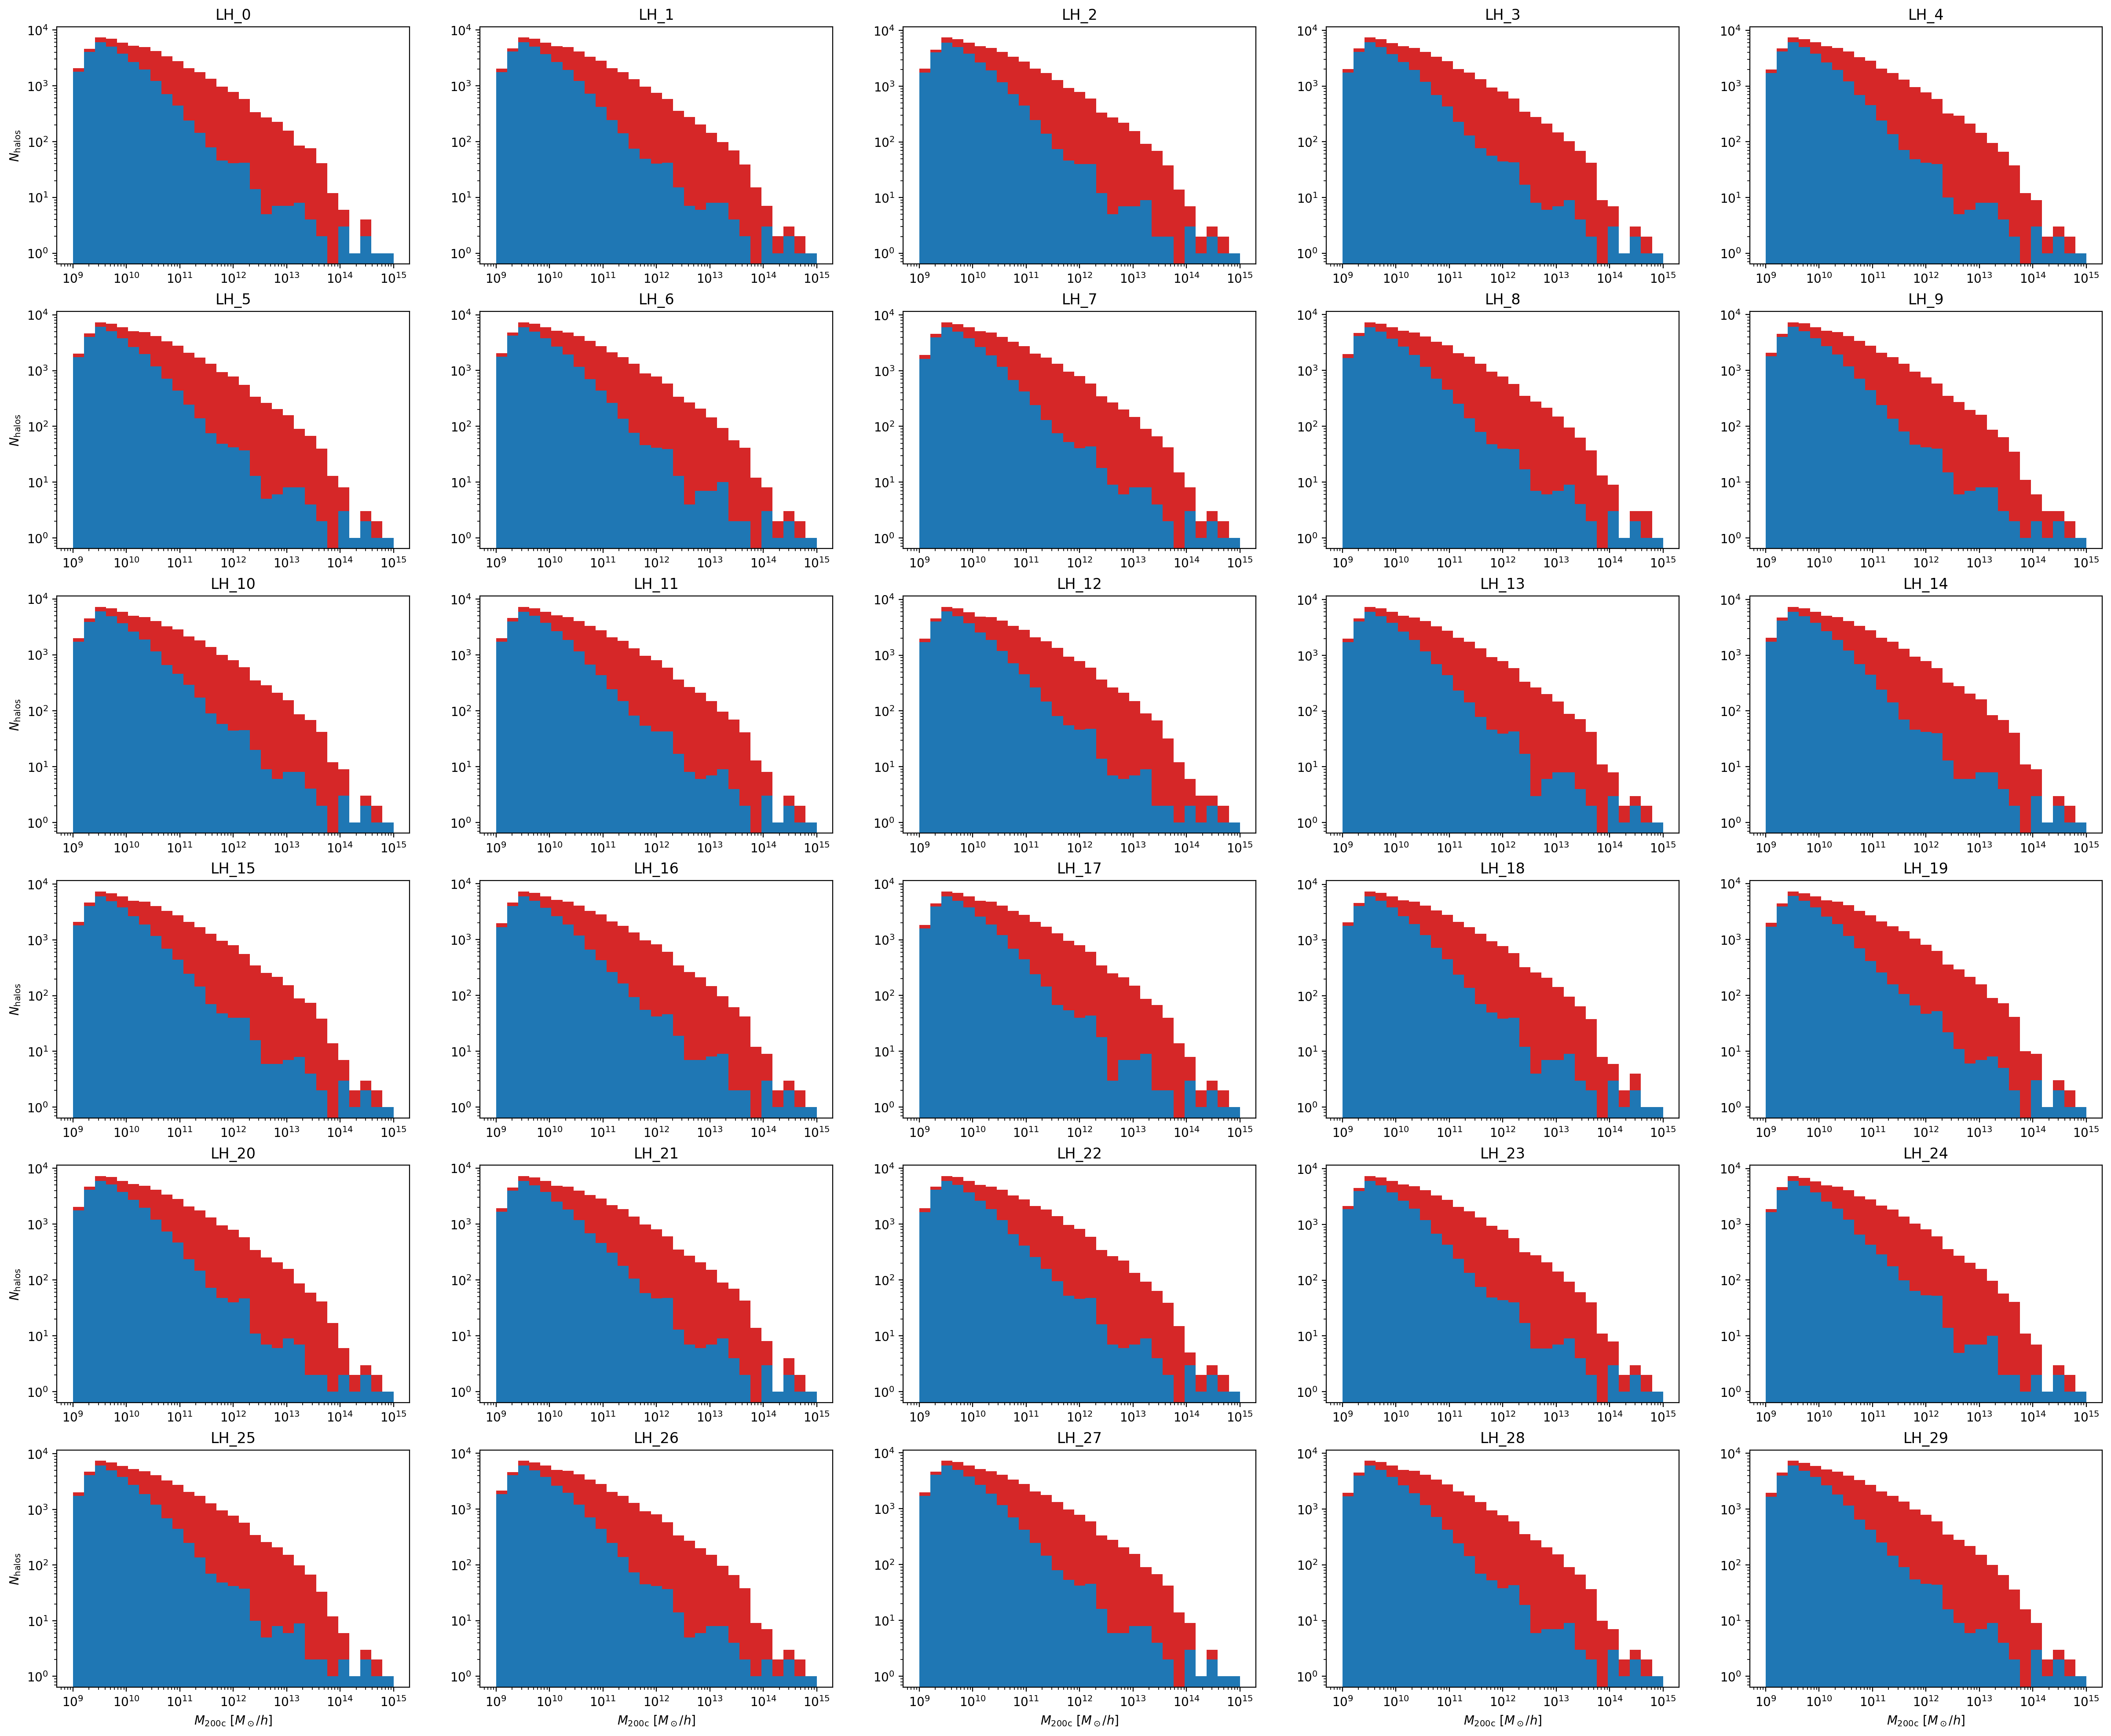

In [149]:
fig, ax = plt.subplots(6, 5, dpi=200, figsize=(30, 25))

for i in range(6):
    for j in range(5):
        ax[i,j].set_xscale('log')
        ax[i,j].set_yscale('log')

        ax[i,j].hist(1e10*zoom[name_list[5*i+j]].fof['halo_m200c'], color='C3', bins=np.logspace(9,15,30))
        ax[i,j].hist(1e10*zoom[name_list[5*i+j]].fof['halo_m200c'][pol[name_list[5*i+j]]<0.002], color='C0', bins=np.logspace(9,15,30))

        ax[i,j].set_title(name_list[5*i+j])

        if j==0:
           ax[i,j].set_ylabel(r"$N_\mathrm{halos}$")
        if i==5:
            ax[i,j].set_xlabel(r"$M_\mathrm{200c}\ [M_\odot/h]$")

2025-11-25 16:28:36,231 bacco.sims : Reading 139956 items for Group_M_Crit500


Text(0.5, 0, '$M_\\mathrm{200c}\\ [M_\\odot/h]$')

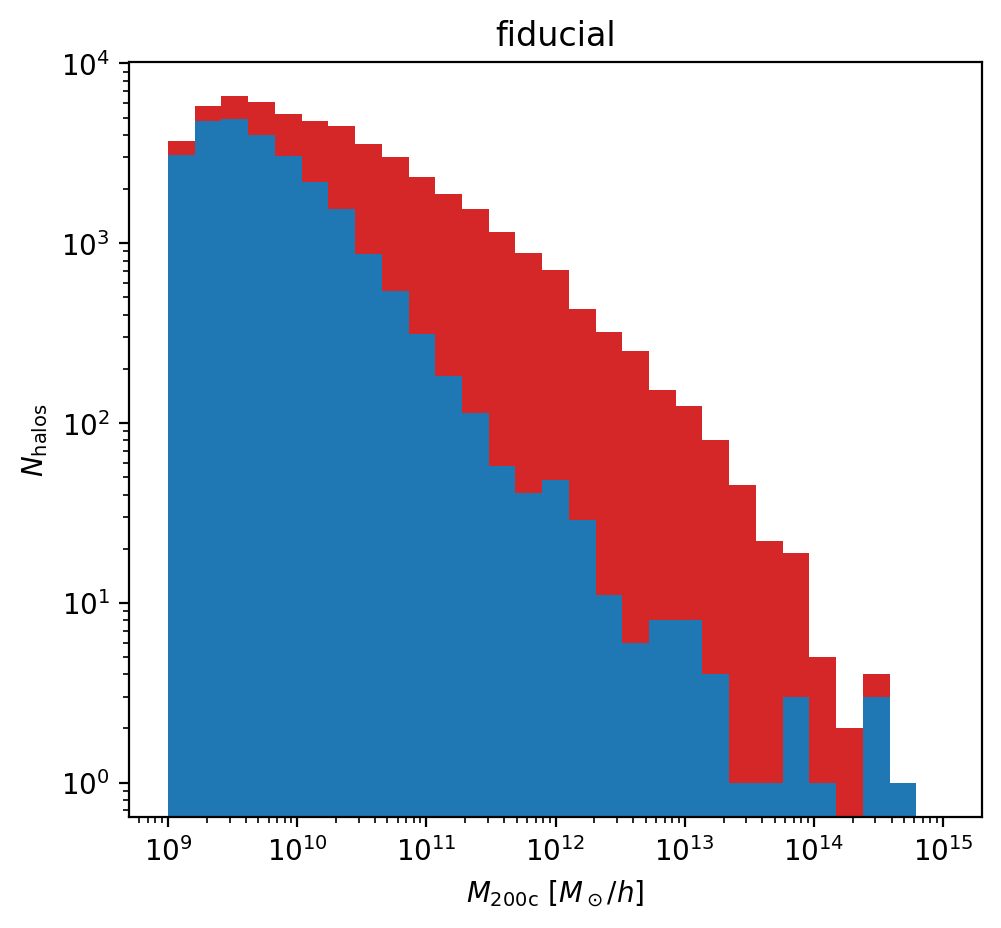

In [157]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5, 5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.hist(1e10*zoom['fiducial'].fof['halo_m500c'], color='C3', bins=np.logspace(9,15,30))
ax.hist(1e10*zoom['fiducial'].fof['halo_m500c'][pol['fiducial']<0.002], color='C0', bins=np.logspace(9,15,30))

ax.set_title('fiducial')

ax.set_ylabel(r"$N_\mathrm{halos}$")
ax.set_xlabel(r"$M_\mathrm{200c}\ [M_\odot/h]$")

In [151]:
xmatch = {}

for i in range(len(name_list)):
    xmatch[name_list[i]] = utils.cross_match(zoom[name_list[i]], snap=264)

2025-11-25 16:01:46,675 bacco.sims : Initialising simulation Default
2025-11-25 16:01:46,677 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-25 16:01:46,679 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-25 16:01:46,731 bacco.sims : ...done in 0.00754 s
2025-11-25 16:01:46,737 bacco.sims : Reading 98233510 items for GroupPos


2025-11-25 16:01:53,649 bacco.sims : Reading 90246895 items for SubhaloPos
2025-11-25 16:01:59,029 bacco.sims : Reading 142791 items for GroupPos
2025-11-25 16:01:59,371 bacco.sims : Reading 142791 items for Group_M_Mean200
2025-11-25 16:01:59,424 bacco.sims : Reading 98233510 items for Group_M_Mean200
2025-11-25 16:02:14,706 bacco.sims : Reading 76572 items for SubhaloVmax
2025-11-25 16:02:14,799 bacco.sims : Reading 142791 items for halo_firstsub
2025-11-25 16:02:14,880 bacco.sims : Reading 90246895 items for SubhaloVmax
2025-11-25 16:02:53,208 bacco.sims : Reading 98233510 items for halo_firstsub
/cosmos_storage/home/fgmaion/MTNG-resims/src/utils.py:852: RuntimeWarning: divide by zero encountered in divide
  
2025-11-25 16:03:09,541 bacco.sims : Initialising simulation Default
2025-11-25 16:03:09,543 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-25 16:03:09,546 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/grou

In [152]:
base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/DM_only/output/"
zoom_dmo = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap),\
                        sim_format='TNG500', fixedPk=True, use_orphans=False, tau=tau, ns=ns, sigma8=sigma8,\
                        tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(snap,snap), use_ids=True, numpart=4320)

2025-11-25 16:19:35,687 bacco.sims : Initialising simulation Default
2025-11-25 16:19:35,688 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/DM_only/output/groups_264/fof_subhalo_tab_264
2025-11-25 16:19:35,729 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/DM_only/output/groups_264/fof_subhalo_tab_264


2025-11-25 16:19:36,296 bacco.sims : ...done in 0.0691 s


In [153]:
xmatch_dmo = utils.cross_match(zoom_dmo, snap=264)

2025-11-25 16:19:36,328 bacco.sims : Initialising simulation Default
2025-11-25 16:19:36,329 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-25 16:19:36,332 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-25 16:19:36,375 bacco.sims : ...done in 0.00711 s
2025-11-25 16:19:36,382 bacco.sims : Reading 98233510 items for GroupPos


2025-11-25 16:19:44,175 bacco.sims : Reading 90246895 items for SubhaloPos
2025-11-25 16:19:49,530 bacco.sims : Reading 72944 items for GroupPos
2025-11-25 16:19:49,909 bacco.sims : Reading 72944 items for Group_M_Mean200
2025-11-25 16:19:49,938 bacco.sims : Reading 98233510 items for Group_M_Mean200
2025-11-25 16:19:52,331 bacco.sims : Reading 74436 items for SubhaloVmax
2025-11-25 16:19:52,356 bacco.sims : Reading 72944 items for halo_firstsub
2025-11-25 16:19:52,395 bacco.sims : Reading 90246895 items for SubhaloVmax
2025-11-25 16:19:54,934 bacco.sims : Reading 98233510 items for halo_firstsub


In [154]:
xmatch_MTNG_dm = utils.cross_match(mtng_dm, snap=264)

2025-11-25 16:20:10,194 bacco.sims : Initialising simulation Default
2025-11-25 16:20:10,196 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-25 16:20:10,199 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2025-11-25 16:20:10,236 bacco.sims : ...done in 0.00788 s
2025-11-25 16:20:10,240 bacco.sims : Reading 98233510 items for GroupPos


2025-11-25 16:20:15,684 bacco.sims : Reading 90246895 items for SubhaloPos
2025-11-25 16:20:31,254 bacco.sims : Reading 11273943 items for Group_M_Mean200
2025-11-25 16:20:32,800 bacco.sims : Reading 98233510 items for Group_M_Mean200
2025-11-25 16:20:35,004 bacco.sims : Reading 14199653 items for SubhaloVmax
2025-11-25 16:20:39,009 bacco.sims : Reading 11273943 items for halo_firstsub
2025-11-25 16:20:41,152 bacco.sims : Reading 90246895 items for SubhaloVmax
2025-11-25 16:20:43,362 bacco.sims : Reading 98233510 items for halo_firstsub


Text(0, 0.5, '$N_\\mathrm{halos}$')

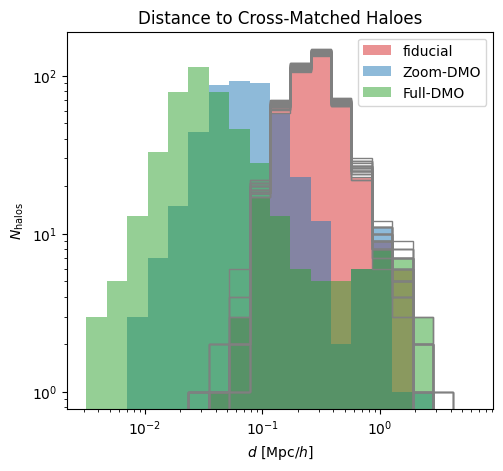

In [155]:
fig, ax = plt.subplots(dpi=100, figsize=(5.5, 5))

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_title('Distance to Cross-Matched Haloes')

for i in range(len(name_list)-1):
    ax.hist(xmatch[name_list[i]]['d'], bins=np.logspace(-2.5,0.8,20), alpha=1, histtype='step', color='gray')

ax.hist(xmatch['fiducial']['d'], bins=np.logspace(-2.5,0.8,20), color='C3', alpha=0.5, label='fiducial')
ax.hist(xmatch_dmo['d'], bins=np.logspace(-2.5,0.8,20), alpha=0.5, label='Zoom-DMO', color='C0')
ax.hist(xmatch_MTNG_dm['d'], bins=np.logspace(-2.5,0.8,20), alpha=0.5, label='Full-DMO', color='C2', linestyle='--')

ax.legend()

ax.set_xlabel(r"$d\ [\mathrm{Mpc}/h]$")
ax.set_ylabel(r"$N_\mathrm{halos}$")

In [156]:
def fgas_m500c(hydro):
    cont = hydro.fof['halo_masstype']

    m500c = hydro.fof['halo_m500c'] * 1e10
    r500c = hydro.fof['halo_r500c']
    
    sel = np.where(m500c > 1e10)[0]
    fgas = np.zeros(len(sel))
    for i in range(len(sel)):
        dist = np.sqrt(np.sum((hydro.sub['pos'] - hydro.fof['halo_pos'][sel[i]])**2, axis=1))
        mask = dist < r500c[sel[i]]
        mgas_500c = np.sum(hydro.sub['MassType'][mask,0]*1e10)
        fgas[i] = mgas_500c / m500c[sel[i]]

    return fgas

In [ ]:
old_hist = {}
new_hist = {}

for snap in range(100,245):
    LH0 = {}

    base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/old_LH0/hydro_output/"
    LH0["old"] = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap),\
                            sim_format='TNG500', fixedPk=True, use_orphans=False,\
                            tau=tau, ns=ns, sigma8=sigma8, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(snap,snap),\
                            use_ids=True, numpart=4320)

    base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/"
    LH0["new"] = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap),\
                            sim_format='TNG500', fixedPk=True, use_orphans=False,\
                            tau=tau, ns=ns, sigma8=sigma8, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(snap,snap),\
                            use_ids=True, numpart=4320)

    # sel_old = LH0['old'].sub['MassType'][:,4] > 0.1
    # sel_new = LH0['new'].sub['MassType'][:,4] > 0.1

    old_hist[snap] = np.histogram(np.log10(LH0['old'].sub['MassType'][:,4]*1e10), bins=np.linspace(9, 12, 31))[0]
    new_hist[snap] = np.histogram(np.log10(LH0['new'].sub['MassType'][:,4]*1e10), bins=np.linspace(9, 12, 31))[0]

2025-11-11 02:30:15,177 bacco.sims : Initialising simulation Default
2025-11-11 02:30:15,179 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/old_LH0/hydro_output/groups_100/fof_subhalo_tab_100
2025-11-11 02:30:15,198 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/old_LH0/hydro_output/groups_100/fof_subhalo_tab_100
2025-11-11 02:30:15,500 bacco.sims : ...done in 0.0554 s
2025-11-11 02:30:15,502 bacco.sims : Initialising simulation Default
2025-11-11 02:30:15,502 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/groups_100/fof_subhalo_tab_100
2025-11-11 02:30:15,520 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/groups_100/fof_subhalo_tab_100
2025-11-11 02:30:15,970 bacco.sims : ...done in 0.0381 s
2025-11-11 02:30:16,108 bacco.sims : Reading 119692 items for SubhaloMassType
/tmp/ipykernel_206947/2612984103.py:22: RuntimeWarning: divide by zero encountered in log10
  ol

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].set_yscale('log')

for snap in range(100,245):
    ax[0].plot(bin_centers, old_hist[snap], alpha=1, color='C0')
    ax[0].plot(bin_centers, new_hist[snap], alpha=1, color='C3')

ratio = np.zeros((145, 30))
for snap in range(100,245):
    ratio[snap-100,:] = old_hist[snap]/new_hist[snap]
    ax[1].plot(bin_centers, old_hist[snap]/new_hist[snap], alpha=0.5, color='C0')

ax[1].plot(bin_centers, np.mean(ratio, axis=0), color='k', lw=2)

ax[1].axhline(1, color='k', ls='--')
ax[1].set_ylim(0.5, 1.5)
